In [ ]:
import json
from hmac import new
from logging import raiseExceptions

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import multipletests
from itertools import combinations
from collections import Counter
import os

from sympy.codegen.ast import continue_

# Set seaborn theme globally
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.2)

# ===========================================================================
# 1. Helper Functions (Ported from visualizations.ipynb)
# ===========================================================================

def get_path_for_strat(strat):
    """Returns df_h, df_rl_summary, df_rl_traj"""
    if strat not in ["multiply", "evenly", "by_effort"]:
        raise ValueError(f"Invalid strategy: {strat}. Must be one of ['multiply', 'evenly', 'by_effort']")

    h_file = f"results/reward_summary_by_archetype_{strat}.parquet"
    rl_summary_file = f"results/rl_summary_by_archetype_{strat}.parquet"
    rl_traj_file = f"results/rl_trajectories_{strat}.parquet"

    if not all(os.path.exists(f) for f in [h_file, rl_summary_file, rl_traj_file]):
        print(f"Skipping {strat}: Files not found.")
        return None, None, None

    df_h = pd.read_parquet(h_file)
    df_rl_summary = pd.read_parquet(rl_summary_file)
    df_rl_traj = pd.read_parquet(rl_traj_file)

    return df_h, df_rl_summary, df_rl_traj

def plot_histograms(projects, actions):
    contributors_per_project(projects)
    success_rate_over_time(projects)
    quality_metrics_over_time(projects)
    collab_metrics_over_time(projects)
    projects_per_contributor(projects)
    completion_per_project(projects)
    quality_per_project(projects)

def contributors_per_project(projects):
    num_contributors = [len(p["contributors"]) for p in projects]
    plt.figure(figsize=(8, 5))
    sns.histplot(num_contributors, bins=range(1, max(num_contributors) + 2), kde=False, discrete=True)
    plt.xlabel("Number of Contributors")
    plt.ylabel("Number of Projects")
    plt.title("Distribution of Contributors per Project")
    plt.tight_layout()
    plt.show()

def success_rate_over_time(projects):
    events = [(p["start_time"], p["finished"], p["final_reward"]) for p in projects]
    events.sort(key=lambda x: x[0])
    time_steps, success_rates = [], []
    finished, successful = 0, 0
    for t, is_finished, score in events:
        if is_finished:
            finished += 1
            if score > 0: successful += 1
        success_rates.append(successful / finished if finished > 0 else 0)
        time_steps.append(t)
    plt.figure(figsize=(8, 5))
    sns.lineplot(x=time_steps, y=success_rates)
    plt.xlabel("Time Step")
    plt.ylabel("Success Rate")
    plt.title("Project Success Rate Over Time")
    plt.ylim(0, 1.05)
    plt.tight_layout()
    plt.show()

def quality_metrics_over_time(projects):
    projects_per_time = {p["start_time"]:[] for p in projects}
    for p in projects: projects_per_time[p["start_time"]].append(p)
    projects_sorted = sorted(projects_per_time.items(), key=lambda p: p[0])
    times = [t for t, _ in projects_sorted]
    quality = [np.mean([p["quality_score"] for p in pjs]) for _, pjs in projects_sorted]
    novelty = [np.mean([p["novelty_score"] for p in pjs]) for _, pjs in projects_sorted]
    value = [np.mean([p["societal_value_score"] for p in pjs]) for _, pjs in projects_sorted]
    plt.figure(figsize=(10, 6))
    sns.lineplot(x=times, y=quality, label="Quality Score")
    sns.lineplot(x=times, y=novelty, label="Novelty")
    sns.lineplot(x=times, y=value, label="Societal Value")
    plt.xlabel("Time Step")
    plt.ylabel("Value")
    plt.title("Project Metrics Over Time")
    plt.legend()
    plt.show()

def collab_metrics_over_time(projects):
    projects_per_time = {p["start_time"]: [] for p in projects}
    for p in projects: projects_per_time[p["start_time"]].append(p)
    projects_sorted = sorted(projects_per_time.items(), key=lambda p: p[0])
    times = [t for t, _ in projects_sorted]
    effort = [np.mean([p["current_effort"] for p in pjs]) for _, pjs in projects_sorted]
    n_contributors = [np.mean([len(p["contributors"]) for p in pjs]) for _, pjs in projects_sorted]
    citations = [np.sum([len(p.get("citations", [])) for p in pjs]) for _, pjs in projects_sorted]
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)
    sns.lineplot(x=times, y=effort, ax=axes[0])
    axes[0].set_title("Current Effort")
    sns.lineplot(x=times, y=n_contributors, ax=axes[1])
    axes[1].set_title("# Contributors per Paper")
    sns.lineplot(x=times, y=citations, ax=axes[2])
    axes[2].set_title("Citations")
    plt.tight_layout()
    plt.show()

def projects_per_contributor(projects):
    all_contributors = []
    for p in projects: all_contributors.extend(p["contributors"])
    author_counts = Counter(all_contributors)
    papers_per_author = list(author_counts.values())
    plt.figure(figsize=(8, 5))
    sns.histplot(papers_per_author, bins=range(1, max(papers_per_author) + 2), kde=False, discrete=True)
    plt.xlabel("Number of Papers per Author")
    plt.ylabel("Number of Authors")
    plt.title("Authors by Number of Papers")
    plt.tight_layout()
    plt.show()

def completion_per_project(projects):
    completion = [max(0, p["current_effort"] / p["required_effort"]) * 100 for p in projects]
    plt.figure(figsize=(8, 5))
    sns.histplot(completion, bins=range(0, 110, 10), kde=False)
    plt.xlabel("Completion (%)")
    plt.ylabel("Number of Projects")
    plt.title("Distribution of Project Completion")
    plt.tight_layout()
    plt.show()

def quality_per_project(projects):
    quality_scores = [p["quality_score"] for p in projects]
    plt.figure(figsize=(8, 5))
    sns.histplot(quality_scores, bins=[i/10 for i in range(0, 11)], kde=False)
    plt.xlabel("Quality Score")
    plt.ylabel("Number of Projects")
    plt.title("Distribution of Project Quality Scores")
    plt.tight_layout()
    plt.show()

# ===========================================================================
# 2. RL Specific Visualization Functions
# ===========================================================================

def plot_mean_reward_trajectories_with_rl(dfs_heuristic, df_rl, strategy_name="by_effort", normalize=True):
    df_h, df_r = dfs_heuristic.copy(), df_rl.copy()
    all_archetypes = sorted(list(df_h["archetype"].unique()))
    palette = sns.color_palette("tab10", len(all_archetypes) + 1)
    color_map = {a: palette[i] for i, a in enumerate(all_archetypes)}
    color_map["rl_agent"] = "red"
    plt.figure(figsize=(12, 7))
    if normalize:
        max_val = max(df_h["mean_reward"].max(), df_r["mean_reward"].max())
        if max_val > 0:
            df_h["mean_reward"] /= max_val
            df_r["mean_reward"] /= max_val
    for archetype, group_arch in df_h.groupby("archetype"):
        summary_h = group_arch.groupby("step")["mean_reward"].mean().reset_index()
        plt.plot(summary_h["step"], summary_h["mean_reward"], label=archetype, color=color_map[archetype], lw=2, alpha=0.7)
    summary_rl = df_r.groupby("step").agg(mean_across_seeds=("mean_reward", "mean"), std_across_seeds=("mean_reward", "std")).reset_index()
    plt.plot(summary_rl["step"], summary_rl["mean_across_seeds"], label="rl_agent (PPO)", color=color_map["rl_agent"], lw=4, zorder=5)
    plt.fill_between(summary_rl["step"], summary_rl["mean_across_seeds"] - summary_rl["std_across_seeds"], summary_rl["mean_across_seeds"] + summary_rl["std_across_seeds"], color=color_map["rl_agent"], alpha=0.2, zorder=4)
    plt.title(f"Performance Comparison: RL_Agent vs. Heuristics ({strategy_name})")
    plt.ylabel("Normalized Accumulated Reward" if normalize else "Accumulated Reward")
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

def plot_rl_metrics_distribution(df_rl, strategy_name="by_effort"):
    final_states = df_rl[df_rl["archetype"] == "rl_agent"].groupby("seed").last().reset_index()
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    sns.boxplot(y=final_states["h_index"], ax=axes[0], color="skyblue")
    sns.stripplot(y=final_states["h_index"], ax=axes[0], color="black", alpha=0.5)
    axes[0].set_title(f"RL Agent H-Index Distribution ({strategy_name})")
    sns.boxplot(y=final_states["age"], ax=axes[1], color="lightgreen")
    sns.stripplot(y=final_states["age"], ax=axes[1], color="black", alpha=0.5)
    axes[1].set_title(f"RL Agent Lifespan Distribution ({strategy_name})")
    plt.tight_layout()
    plt.show()


def aggregate_empirical_results(strat):
    df_h, df_rl_summary, df_rl_traj = get_path_for_strat(strat)
    # 1. Plot Performance Curves
    plot_mean_reward_trajectories_with_rl(df_h, df_rl_summary, strategy_name=strat)

    # 2. Plot Distribution Metrics
    plot_rl_metrics_distribution(df_rl_traj, strategy_name=strat)

    # 3. Statistical Summary
    final_step = df_rl_summary["step"].max()
    rl_final = df_rl_summary[df_rl_summary["step"] == final_step]["mean_reward"].mean()
    h_final = df_h[df_h["step"] == final_step].groupby("archetype")["mean_reward"].mean()

    print(f"\n--- Final Mean Reward (Step {final_step}) for {strat} ---")
    print(f"RL_Agent: {rl_final:.2f}")
    for arch, val in h_final.items():
        print(f"{arch:18}: {val:.2f}")

    best_h_val = h_final.max()
    diff = ((rl_final / best_h_val) - 1) * 100
    print(f"\nRL Agent is {diff:+.1f}% better than the best heuristic ({h_final.idxmax()}).")





## 1. Aggregate Empirical Results (RL vs Heuristics)


### "multiply"

In [ ]:
aggregate_empirical_results("multiply")



### "by_effort"

In [ ]:
aggregate_empirical_results("by_effort")

### "evenly"

In [ ]:
aggregate_empirical_results("evenly")

## 2. Detailed Simulation Analysis (Single Seed)
This section performs a deep dive into one specific RL simulation run.


In [ ]:
# Configuration for deep dive
SEED = 110
STRAT = "by_effort" # Change this to "multiply" or "evenly" if desired

try:
    proj_file = f"log/rl_ppo_{STRAT}_s{SEED}_projects.json"
    act_file = f"log/rl_ppo_{STRAT}_s{SEED}_actions.jsonl"

    with open(proj_file, "r") as f:
        projects = json.load(f)
    with open(act_file, "r") as f:
        actions = [json.loads(line) for line in f]
    print(f"✅ Loaded detailed logs for Seed {SEED} ({STRAT})")

    # Run the standard visualization suite
    plot_histograms(projects, actions)
except FileNotFoundError as e:
    print(f"❌ Could not load detailed logs for Seed {SEED} ({STRAT}): {e}")


In [ ]:
# ### Archetype Proportions Over Time
# Tracks how the population composition (heuristic types + RL agent) changes during the run.

In [ ]:
def visualize_policy_population(simulation_steps):
    records = []
    for step_idx, step in enumerate(simulation_steps):
        for agent_id, agent in step.items():
            if agent is not None:
                records.append({"step": step_idx, "archetype": agent.get("archetype", "rl_agent")})
    df = pd.DataFrame(records)
    counts = df.groupby(["step", "archetype"]).size().reset_index(name="count")
    pivot = counts.pivot(index="step", columns="archetype", values="count").fillna(0)

    fig, axes = plt.subplots(2, 1, figsize=(12, 8), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)
    pivot.plot.line(ax=axes[0])
    axes[0].set_title("Population Composition Over Time")
    axes[0].legend(title="Archetype", bbox_to_anchor=(1.05, 1), loc="upper left")
    pivot.sum(axis=1).plot(ax=axes[1], color="black")
    axes[1].set_ylabel("Total Agents")
    plt.tight_layout()
    plt.show()

if 'actions' in locals():
    visualize_policy_population(actions)


## 3. Comparison of Reward Functions across ALL Archetypes (including RL Agent)


Processing archetype: careerist ...

Archetype: careerist
conventional vs fractional          | sig. proportion:  0.153 | min p(FDR):  0.00001 | median p(FDR):  0.94827 | valid tests: 588/600
conventional vs by effort           | sig. proportion:  0.000 | min p(FDR):  0.86390 | median p(FDR):  0.86390 | valid tests: 588/600
fractional vs by effort             | sig. proportion:  0.078 | min p(FDR):  0.00035 | median p(FDR):  0.24993 | valid tests: 588/600

Processing archetype: orthodox_scientist ...

Archetype: orthodox_scientist
conventional vs fractional          | sig. proportion:  0.975 | min p(FDR):  0.00000 | median p(FDR):  0.00000 | valid tests: 593/600
conventional vs by effort           | sig. proportion:  0.000 | min p(FDR):  0.93950 | median p(FDR):  0.93950 | valid tests: 593/600
fractional vs by effort             | sig. proportion:  0.975 | min p(FDR):  0.00000 | median p(FDR):  0.00000 | valid tests: 593/600

Processing archetype: mass_producer ...

Archetype: mass_pr

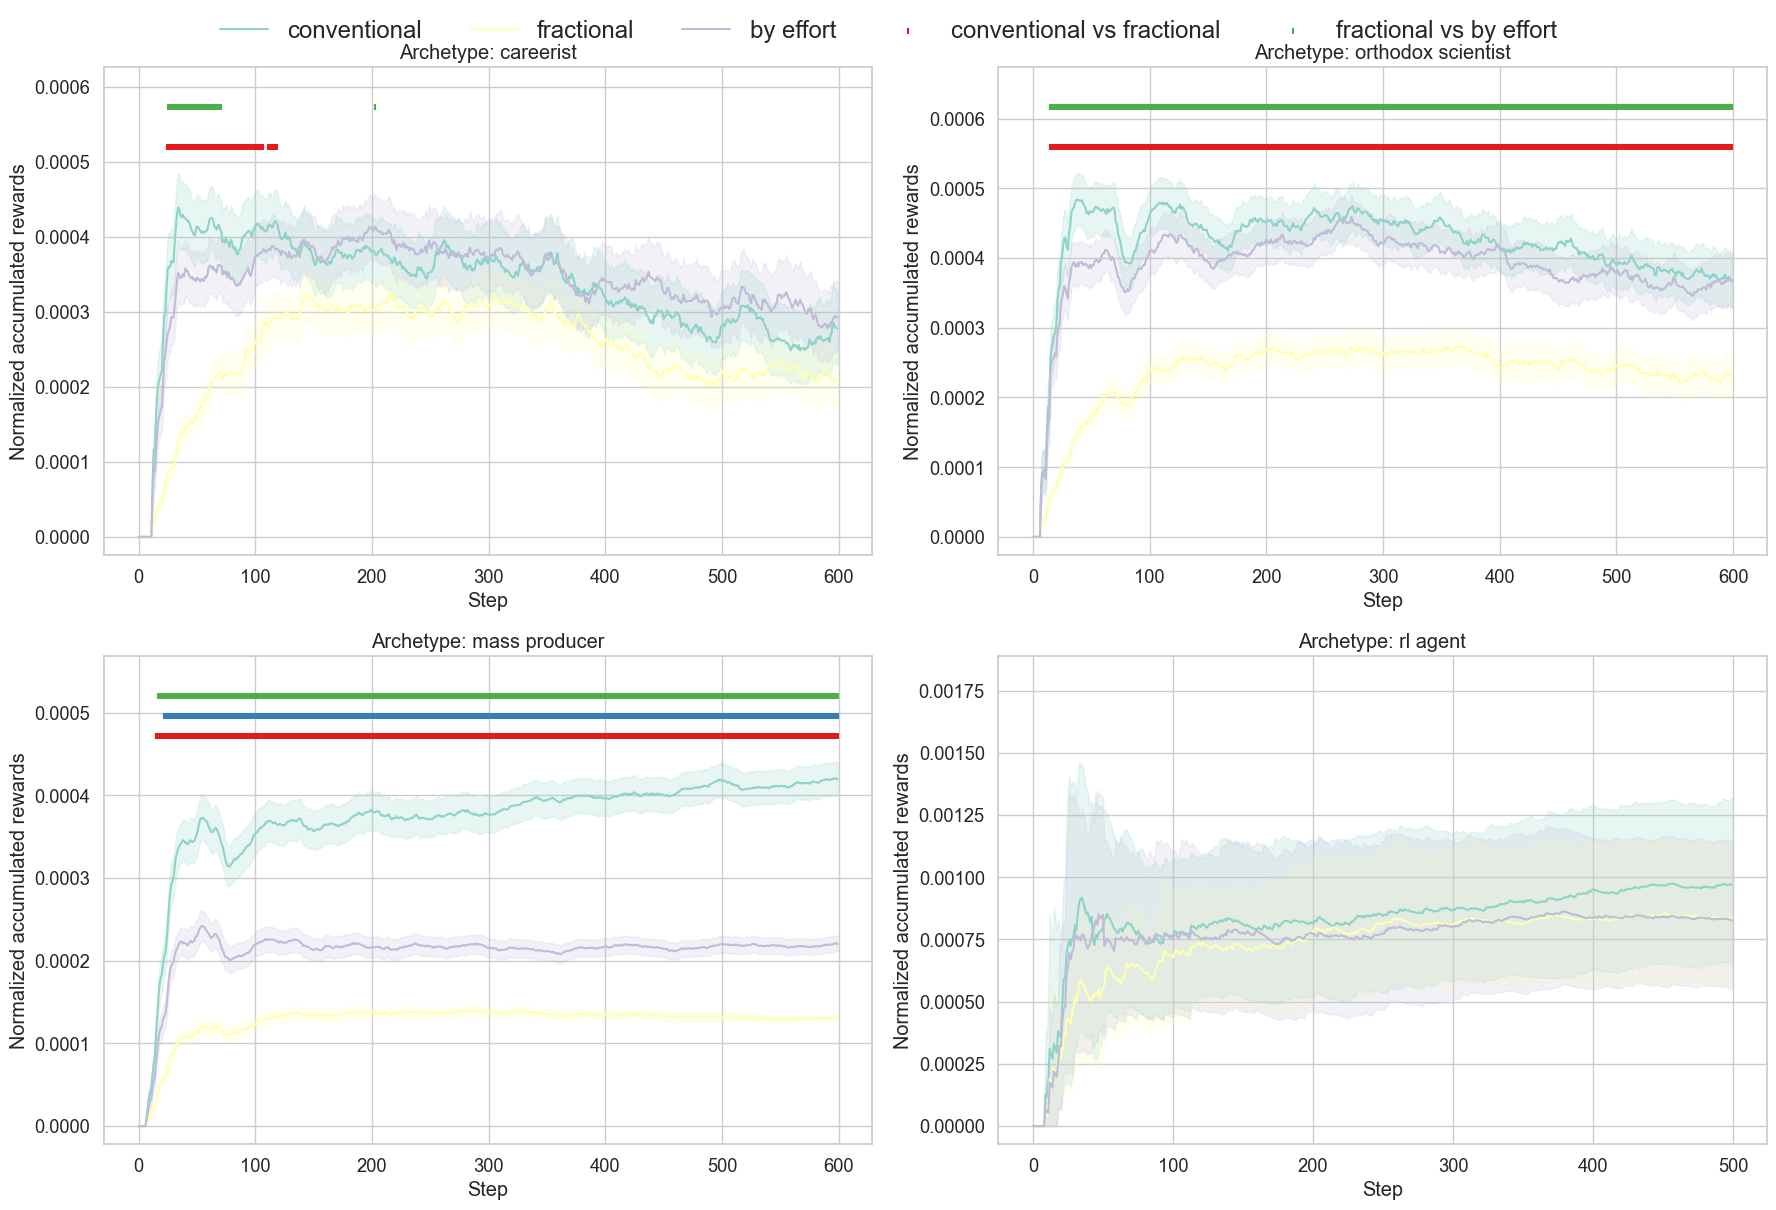

In [14]:
from scipy import stats
from statsmodels.stats.multitest import multipletests
from itertools import combinations

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


# =========================================================
# CONFIG
# =========================================================

variants = {
    "multiply": "conventional",
    "even": "fractional",
    "by_effort": "by effort"
}

archetypes = [
    "careerist",
    "orthodox_scientist",
    "mass_producer",
    "rl_agent"
]

time_steps = list(range(600))
pairs = list(combinations(variants.keys(), 2))
pair_colors = ['#e41a1c', '#377eb8', '#4daf4a']  # red, blue, green

USE_AGE_NORMALIZATION = True
ALPHA = 0.05
FDR_METHOD = "fdr_bh"
N_BOOT = 2000
CI_MODE = "ci"   # or "se"


# =========================================================
# LOAD DATA
# =========================================================

dfs = {}

for v in variants:
    heuristic_path = f"results/reward_trajectories_{v if v != 'even' else 'evenly'}.parquet"
    rl_path = f"results/rl_trajectories_{v if v != 'even' else 'evenly'}.parquet"

    # Heuristic data
    df_h = pd.read_parquet(heuristic_path)

    # RL data: only keep rl_agent rows
    df_rl_all = pd.read_parquet(rl_path)
    df_rl_agent = df_rl_all[df_rl_all["archetype"] == "rl_agent"].copy()

    # Combine
    dfs[v] = pd.concat([df_h, df_rl_agent], ignore_index=True)


# =========================================================
# HELPER FUNCTIONS
# =========================================================

def get_archetype_global_max(dfs_dict, arch, reward_col="accumulated_rewards"):
    """
    Compute one common max reward for a given archetype across all variants.
    This avoids each variant being normalized by its own max.
    """
    maxima = []

    for v in dfs_dict:
        subset = dfs_dict[v].loc[dfs_dict[v]["archetype"] == arch, reward_col]
        if not subset.empty:
            maxima.append(subset.max())

    if len(maxima) == 0:
        return np.nan

    return np.nanmax(maxima)


def prepare_plot_data(dfs_dict, arch):
    """
    Build one combined dataframe for a given archetype across all reward variants.
    Applies shared normalization across variants for that archetype.
    """
    plot_data = []

    arch_global_max = get_archetype_global_max(dfs_dict, arch)

    for v in variants:
        df_variant = dfs_dict[v]
        df_subset = df_variant[df_variant["archetype"] == arch].copy()

        if df_subset.empty:
            continue

        df_subset["variant"] = variants[v]

        if pd.notna(arch_global_max) and arch_global_max > 0:
            df_subset["accumulated_rewards"] = df_subset["accumulated_rewards"] / arch_global_max

        if USE_AGE_NORMALIZATION:
            if "age" not in df_subset.columns:
                raise KeyError(f"'age' column missing for variant '{v}' and archetype '{arch}'.")
            df_subset["accumulated_rewards"] = df_subset["accumulated_rewards"] / (df_subset["age"] + 1)

        plot_data.append(df_subset)

    if len(plot_data) == 0:
        return pd.DataFrame()

    return pd.concat(plot_data, ignore_index=True)


def run_pairwise_stats(combined_df, arch):
    """
    For one archetype, compare reward variants pairwise across time steps
    using Mann-Whitney U and FDR correction.
    """
    pairwise_results = {}

    for pair_idx, (distr1, distr2) in enumerate(pairs):
        variant_1_name = variants[distr1]
        variant_2_name = variants[distr2]

        raw_p_values = []
        n_valid_tests = 0

        df1 = combined_df[combined_df["variant"] == variant_1_name]
        df2 = combined_df[combined_df["variant"] == variant_2_name]

        for t in time_steps:
            d1 = df1.loc[df1["step"] == t, "accumulated_rewards"].dropna().values
            d2 = df2.loc[df2["step"] == t, "accumulated_rewards"].dropna().values

            # At least 2 observations per group
            if len(d1) < 2 or len(d2) < 2:
                raw_p_values.append(1.0)
                continue

            # If both groups are constant and identical, no difference possible
            if (
                np.all(d1 == d1[0]) and
                np.all(d2 == d2[0]) and
                d1[0] == d2[0]
            ):
                raw_p_values.append(1.0)
                continue

            try:
                _, p = stats.mannwhitneyu(d1, d2, alternative="two-sided")
                raw_p_values.append(p)
                n_valid_tests += 1
            except ValueError:
                raw_p_values.append(1.0)

        reject, pvals_corrected, _, _ = multipletests(
            raw_p_values,
            alpha=ALPHA,
            method=FDR_METHOD
        )

        label = f"{variant_1_name} vs {variant_2_name}"
        pairwise_results[label] = {
            "reject": reject,
            "pvals_corrected": pvals_corrected,
            "raw_p_values": np.array(raw_p_values),
            "pair_idx": pair_idx,
            "n_valid_tests": n_valid_tests
        }

    # Console summary
    print(f"\n{'=' * 70}")
    print(f"Archetype: {arch}")
    print(f"{'=' * 70}")

    for label, result in pairwise_results.items():
        reject_mask = result["reject"]
        proportion_sig = np.mean(reject_mask)
        min_p_corr = np.min(result["pvals_corrected"])
        median_p_corr = np.median(result["pvals_corrected"])

        print(
            f"{label:<35} | "
            f"sig. proportion: {proportion_sig:>6.3f} | "
            f"min p(FDR): {min_p_corr:>8.5f} | "
            f"median p(FDR): {median_p_corr:>8.5f} | "
            f"valid tests: {result['n_valid_tests']:>3d}/{len(time_steps)}"
        )

    return pairwise_results


def add_significance_bars(ax, pairwise_results):
    """
    Plot significance markers above the line plot.
    """
    y_min, y_max = ax.get_ylim()
    y_range = y_max - y_min

    # Fallback in case plot is flat
    if y_range == 0:
        y_range = 1e-6

    current_height = y_max + (y_range * 0.02)
    step_height = y_range * 0.05

    for label, result in pairwise_results.items():
        is_sig = result["reject"]
        color_idx = result["pair_idx"]
        sig_steps = np.array(time_steps)[is_sig]

        if len(sig_steps) > 0:
            ax.scatter(
                sig_steps,
                [current_height] * len(sig_steps),
                marker='|',
                s=20,
                color=pair_colors[color_idx],
                label=label
            )

        current_height += step_height

    ax.set_ylim(y_min, current_height + step_height)


# =========================================================
# PLOTTING
# =========================================================

sns.set_style("whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(18, 12), sharey=False)
axes_flat = axes.flatten()

for idx, arch in enumerate(archetypes):
    ax = axes_flat[idx]
    print(f"\nProcessing archetype: {arch} ...")

    combined_df = prepare_plot_data(dfs, arch)

    if combined_df.empty:
        ax.set_title(f"Archetype: {arch.replace('_', ' ')} (no data)")
        ax.text(0.5, 0.5, "No data available", ha="center", va="center", transform=ax.transAxes)
        continue

    # --- Plot performance curves ---
    sns.lineplot(
        data=combined_df,
        x="step",
        y="accumulated_rewards",
        hue="variant",
        ax=ax,
        errorbar=(CI_MODE),
        n_boot=N_BOOT,
        seed=10
    )

    # --- Statistical tests ---
    pairwise_results = run_pairwise_stats(combined_df, arch)

    # --- Significance markers ---
    add_significance_bars(ax, pairwise_results)

    # --- Styling ---
    ax.set_title(f"Archetype: {arch.replace('_', ' ')}")
    ax.set_xlabel("Step")
    ax.set_ylabel("Normalized accumulated rewards")

    # Remove per-axis legend, we use a global one
    leg = ax.get_legend()
    if leg:
        leg.remove()

# =========================================================
# GLOBAL LEGEND
# =========================================================

# Rebuild legend entries manually so both line labels and sig labels appear cleanly
handles, labels = axes_flat[0].get_legend_handles_labels()

# Remove duplicate labels while preserving order
seen = set()
unique_handles = []
unique_labels = []

for h, l in zip(handles, labels):
    if l not in seen:
        seen.add(l)
        unique_handles.append(h)
        unique_labels.append(l)

fig.legend(
    unique_handles,
    unique_labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=max(1, len(unique_labels)),
    fontsize="large",
    frameon=False
)

plt.tight_layout()
plt.show()

## Performance Comparison Between the RL Agent and Heuristic Archetypes


Processing reward variant: conventional ...

Reward variant: conventional
rl agent vs careerist                  | sig. proportion:  0.792 | min p(FDR):  0.00000 | median p(FDR):  0.00017 | valid tests: 491/600
rl agent vs orthodox scientist         | sig. proportion:  0.748 | min p(FDR):  0.00088 | median p(FDR):  0.00235 | valid tests: 493/600
rl agent vs mass producer              | sig. proportion:  0.000 | min p(FDR):  0.15140 | median p(FDR):  0.15140 | valid tests: 493/600

Processing reward variant: fractional ...

Reward variant: fractional
rl agent vs careerist                  | sig. proportion:  0.807 | min p(FDR):  0.00000 | median p(FDR):  0.00002 | valid tests: 491/600
rl agent vs orthodox scientist         | sig. proportion:  0.760 | min p(FDR):  0.00002 | median p(FDR):  0.00006 | valid tests: 493/600
rl agent vs mass producer              | sig. proportion:  0.000 | min p(FDR):  1.00000 | median p(FDR):  1.00000 | valid tests: 493/600

Processing reward variant: by e

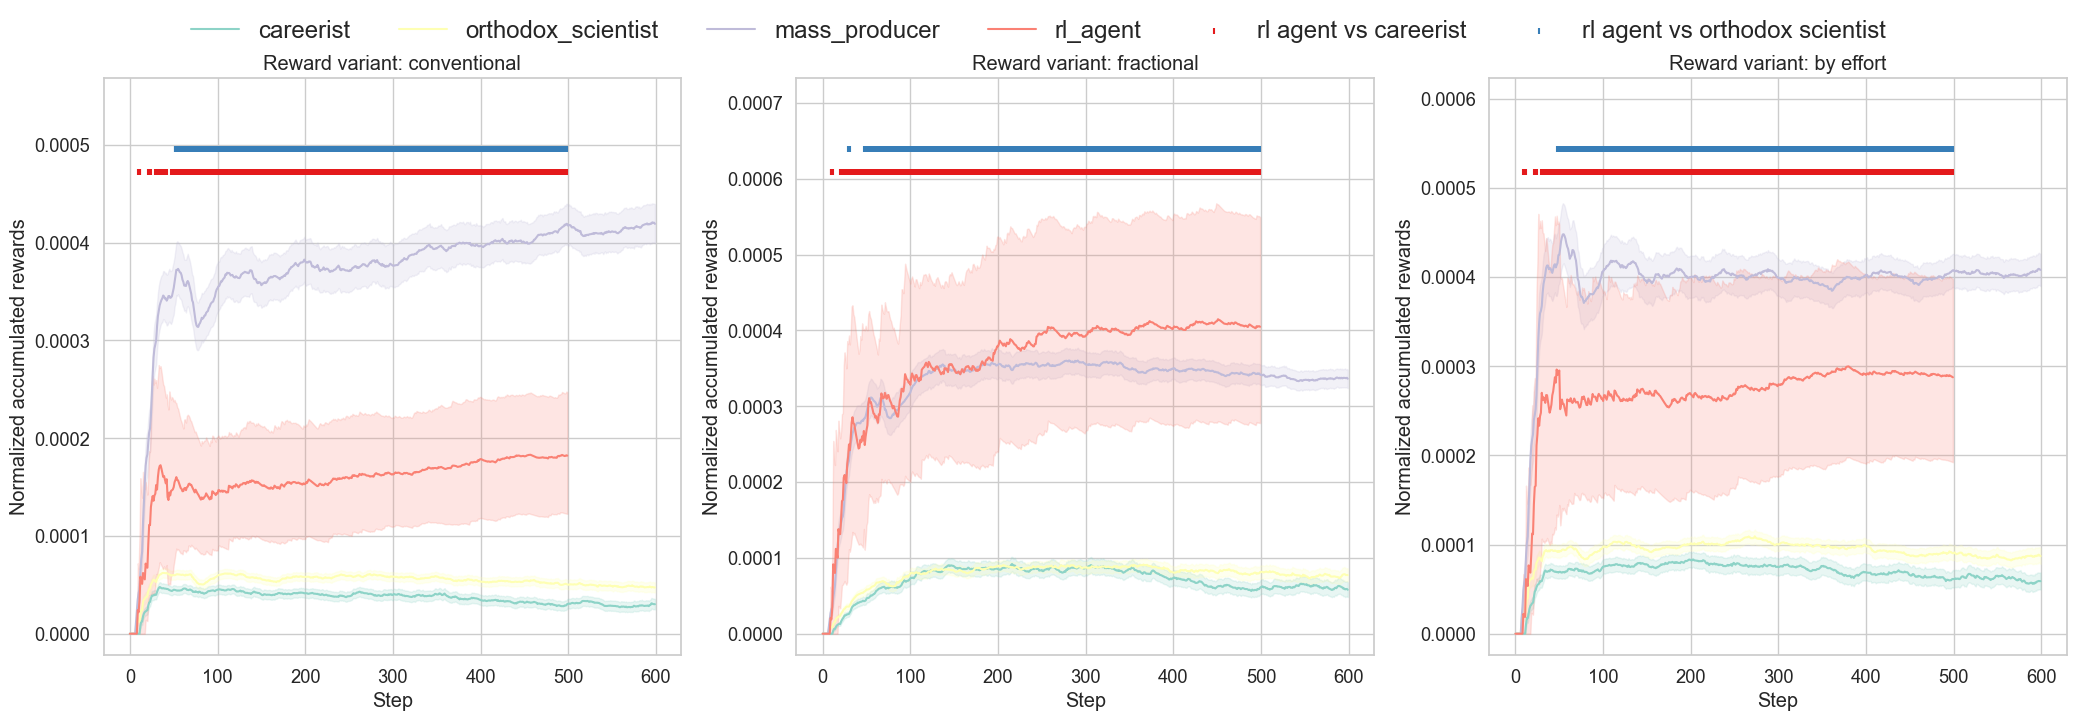

In [15]:
from scipy import stats
from statsmodels.stats.multitest import multipletests
from itertools import combinations

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


# =========================================================
# CONFIG
# =========================================================

variants = {
    "multiply": "conventional",
    "even": "fractional",
    "by_effort": "by effort"
}

archetypes = [
    "careerist",
    "orthodox_scientist",
    "mass_producer",
    "rl_agent"
]

baseline_arch = "rl_agent"
comparison_archetypes = [
    "careerist",
    "orthodox_scientist",
    "mass_producer"
]

time_steps = list(range(600))

# RL agent vs each archetype
pairs = [(baseline_arch, arch) for arch in comparison_archetypes]
pair_colors = {
    ("rl_agent", "careerist"): "#e41a1c",
    ("rl_agent", "orthodox_scientist"): "#377eb8",
    ("rl_agent", "mass_producer"): "#4daf4a"
}

USE_AGE_NORMALIZATION = True
ALPHA = 0.05
FDR_METHOD = "fdr_bh"
N_BOOT = 2000
CI_MODE = "ci"   # "ci" or "se"


# =========================================================
# LOAD DATA
# =========================================================

dfs = {}

for v in variants:
    heuristic_path = f"results/reward_trajectories_{v if v != 'even' else 'evenly'}.parquet"
    rl_path = f"results/rl_trajectories_{v if v != 'even' else 'evenly'}.parquet"

    # Heuristic trajectories
    df_h = pd.read_parquet(heuristic_path)

    # RL trajectories: only keep rl_agent
    df_rl_all = pd.read_parquet(rl_path)
    df_rl_agent = df_rl_all[df_rl_all["archetype"] == "rl_agent"].copy()

    # Merge
    dfs[v] = pd.concat([df_h, df_rl_agent], ignore_index=True)


# =========================================================
# HELPER FUNCTIONS
# =========================================================

def get_variant_global_max(df_variant, reward_col="accumulated_rewards"):
    """
    One shared normalization constant per reward variant across all archetypes.
    This keeps comparisons between rl_agent and archetypes fair within a variant.
    """
    if df_variant.empty:
        return np.nan
    return df_variant[reward_col].max()


def prepare_plot_data_for_variant(df_variant, variant_label):
    """
    Build plotting dataframe for one reward variant across all archetypes.
    Applies one shared normalization constant within the variant.
    """
    plot_df = df_variant.copy()

    if plot_df.empty:
        return pd.DataFrame()

    global_max = get_variant_global_max(plot_df)

    if pd.notna(global_max) and global_max > 0:
        plot_df["accumulated_rewards"] = plot_df["accumulated_rewards"] / global_max

    if USE_AGE_NORMALIZATION:
        if "age" not in plot_df.columns:
            raise KeyError(f"'age' column missing in variant '{variant_label}'.")
        plot_df["accumulated_rewards"] = plot_df["accumulated_rewards"] / (plot_df["age"] + 1)

    return plot_df


def run_rl_vs_archetype_stats(plot_df, variant_name):
    """
    Compare RL agent against each fixed archetype for one reward variant.
    Performs Mann-Whitney U test at each time step, then FDR correction.
    """
    pairwise_results = {}

    print(f"\n{'=' * 80}")
    print(f"Reward variant: {variant_name}")
    print(f"{'=' * 80}")

    for rl_arch, other_arch in pairs:
        raw_p_values = []
        n_valid_tests = 0

        df_rl = plot_df[plot_df["archetype"] == rl_arch]
        df_other = plot_df[plot_df["archetype"] == other_arch]

        for t in time_steps:
            d1 = df_rl.loc[df_rl["step"] == t, "accumulated_rewards"].dropna().values
            d2 = df_other.loc[df_other["step"] == t, "accumulated_rewards"].dropna().values

            # Need at least 2 samples per group
            if len(d1) < 2 or len(d2) < 2:
                raw_p_values.append(1.0)
                continue

            # If both groups are identical constants, no difference
            if (
                np.all(d1 == d1[0]) and
                np.all(d2 == d2[0]) and
                d1[0] == d2[0]
            ):
                raw_p_values.append(1.0)
                continue

            try:
                _, p = stats.mannwhitneyu(d1, d2, alternative="two-sided")
                raw_p_values.append(p)
                n_valid_tests += 1
            except ValueError:
                raw_p_values.append(1.0)

        reject, pvals_corrected, _, _ = multipletests(
            raw_p_values,
            alpha=ALPHA,
            method=FDR_METHOD
        )

        label = f"rl agent vs {other_arch.replace('_', ' ')}"
        pairwise_results[label] = {
            "reject": reject,
            "pvals_corrected": pvals_corrected,
            "raw_p_values": np.array(raw_p_values),
            "pair": (rl_arch, other_arch),
            "color": pair_colors[(rl_arch, other_arch)],
            "n_valid_tests": n_valid_tests
        }

    for label, result in pairwise_results.items():
        proportion_sig = np.mean(result["reject"])
        min_p_corr = np.min(result["pvals_corrected"])
        median_p_corr = np.median(result["pvals_corrected"])

        print(
            f"{label:<38} | "
            f"sig. proportion: {proportion_sig:>6.3f} | "
            f"min p(FDR): {min_p_corr:>8.5f} | "
            f"median p(FDR): {median_p_corr:>8.5f} | "
            f"valid tests: {result['n_valid_tests']:>3d}/{len(time_steps)}"
        )

    return pairwise_results


def add_significance_bars(ax, pairwise_results):
    """
    Add significance markers above the plot.
    """
    y_min, y_max = ax.get_ylim()
    y_range = y_max - y_min

    if y_range == 0:
        y_range = 1e-6

    current_height = y_max + (y_range * 0.02)
    step_height = y_range * 0.05

    for label, result in pairwise_results.items():
        is_sig = result["reject"]
        sig_steps = np.array(time_steps)[is_sig]

        if len(sig_steps) > 0:
            ax.scatter(
                sig_steps,
                [current_height] * len(sig_steps),
                marker="|",
                s=20,
                color=result["color"],
                label=label
            )

        current_height += step_height

    ax.set_ylim(y_min, current_height + step_height)


def prettify_arch_name(name):
    return name.replace("_", " ")


# =========================================================
# PLOTTING
# =========================================================

sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(21, 7), sharey=False)

if len(variants) == 1:
    axes = [axes]

for idx, v in enumerate(variants):
    ax = axes[idx]
    variant_label = variants[v]

    print(f"\nProcessing reward variant: {variant_label} ...")

    df_variant = dfs[v].copy()
    plot_df = prepare_plot_data_for_variant(df_variant, variant_label)

    # Keep only archetypes of interest
    plot_df = plot_df[plot_df["archetype"].isin(archetypes)].copy()

    if plot_df.empty:
        ax.set_title(f"{variant_label} (no data)")
        ax.text(0.5, 0.5, "No data available", ha="center", va="center", transform=ax.transAxes)
        continue

    # Plot all archetypes for this reward variant
    sns.lineplot(
        data=plot_df,
        x="step",
        y="accumulated_rewards",
        hue="archetype",
        hue_order=archetypes,
        ax=ax,
        errorbar=CI_MODE,
        n_boot=N_BOOT,
        seed=10
    )

    # Statistics: rl_agent vs the 3 archetypes
    pairwise_results = run_rl_vs_archetype_stats(plot_df, variant_label)

    # Significance markers
    add_significance_bars(ax, pairwise_results)

    # Styling
    ax.set_title(f"Reward variant: {variant_label}")
    ax.set_xlabel("Step")
    ax.set_ylabel("Normalized accumulated rewards")

    # Remove local legend
    leg = ax.get_legend()
    if leg:
        leg.remove()


# =========================================================
# GLOBAL LEGEND
# =========================================================

# Build legend manually from first axis
handles, labels = axes[0].get_legend_handles_labels()

# Deduplicate while preserving order
seen = set()
unique_handles = []
unique_labels = []

for h, l in zip(handles, labels):
    if l not in seen:
        seen.add(l)
        unique_handles.append(h)
        unique_labels.append(l)

fig.legend(
    unique_handles,
    unique_labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.05),
    ncol=max(1, len(unique_labels)),
    fontsize="large",
    frameon=False
)

plt.tight_layout()
plt.show()